In [379]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import json
import datetime as dt
import matplotlib.ticker as tck

In [380]:
LOG_DIR = Path('/g/data/gb02/public/dashboard/pag548')

Load the default case with no I/O server

In [381]:
default = LOG_DIR / 'AM3_N512_no_ioserver.log'

In [382]:
# Read line by line if dealing with JSON lines
with open(default, 'r') as file:
    data = [json.loads(line) for line in file]

In [383]:
df = pd.json_normalize(data)

In [384]:
df['time'] = pd.to_datetime(df.t, unit = 's')  #Convert linux epoch time into a datetime object
df['time_elapsed'] = df['time'] - df['time'].iloc[0]
df['seconds'] = df['time_elapsed'].dt.total_seconds()  # Required for sensible plotting
df.set_index('time_elapsed',inplace=True)
df.sort_index(inplace=True)  #Make sure you do this otherwise location indexing will fail!
df['rss_bytes_sum'] = df['rss_bytes_sum']/1e9 #Convert to Gb
df['io_read_bytes'] = df['io_read_bytes']/1e9 #Convert to Gb
df['io_write_bytes'] = df['io_write_bytes']/1e9 #Convert to Gb

In [385]:
from matplotlib.ticker import FuncFormatter

# 1. The formatter now expects 'x' to be plain seconds (float)
def format_seconds_to_hms(x, pos):
    hours, remainder = divmod(x, 3600)
    minutes, seconds = divmod(remainder, 60)
    # Handles sub-second precision accurately
    return f"{int(hours):02d}:{int(minutes):02d}:{seconds:06.3f}"

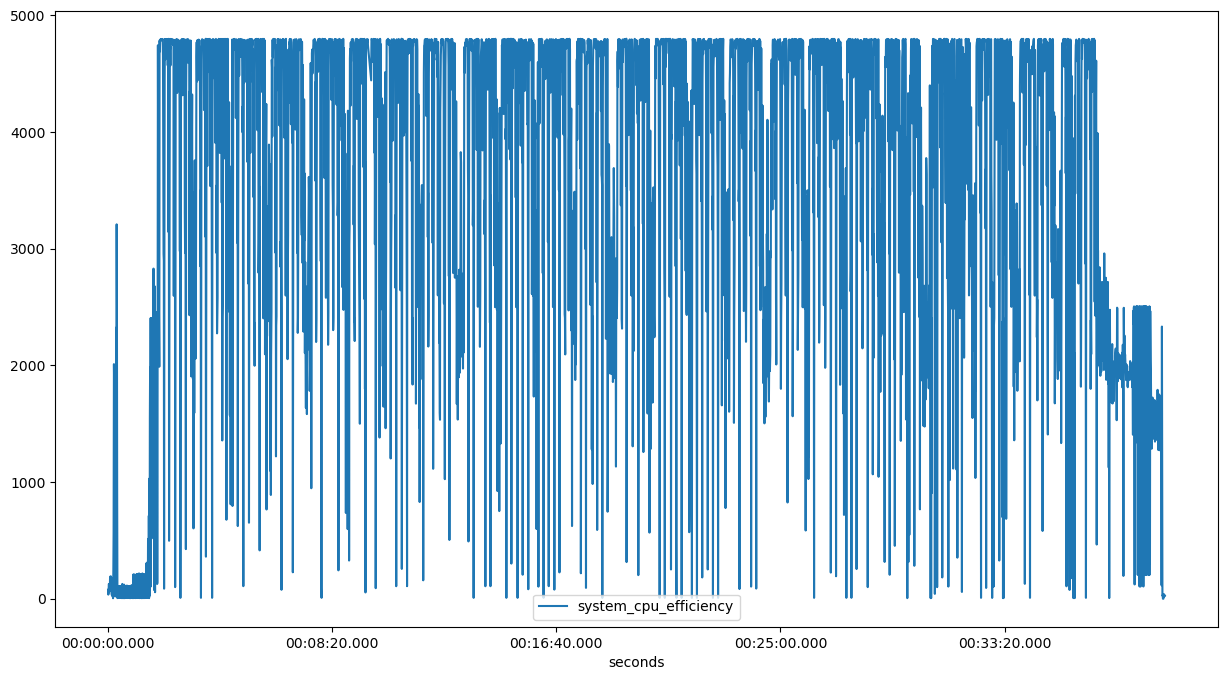

In [386]:
fig,ax = plt.subplots(figsize=(15,8))
df.set_index('seconds')[['system_cpu_efficiency']].plot(ax=ax)
# Define formatter function for minutes and seconds
ax.xaxis.set_major_formatter(FuncFormatter(format_seconds_to_hms))


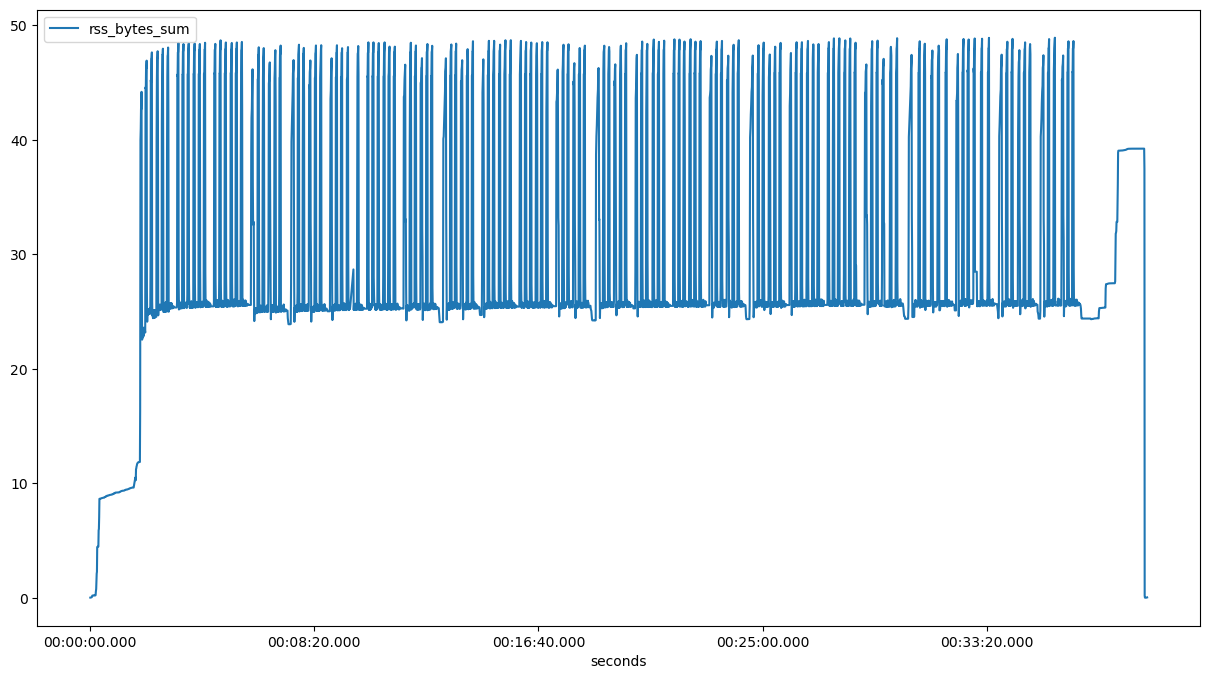

In [387]:
fig,ax = plt.subplots(figsize=(15,8))
df.set_index('seconds')[['rss_bytes_sum']].plot(ax=ax)
# Define formatter function for minutes and seconds
ax.xaxis.set_major_formatter(FuncFormatter(format_seconds_to_hms))

OK according to the standard output 

Let's examine the logs at this point

<Axes: xlabel='seconds'>

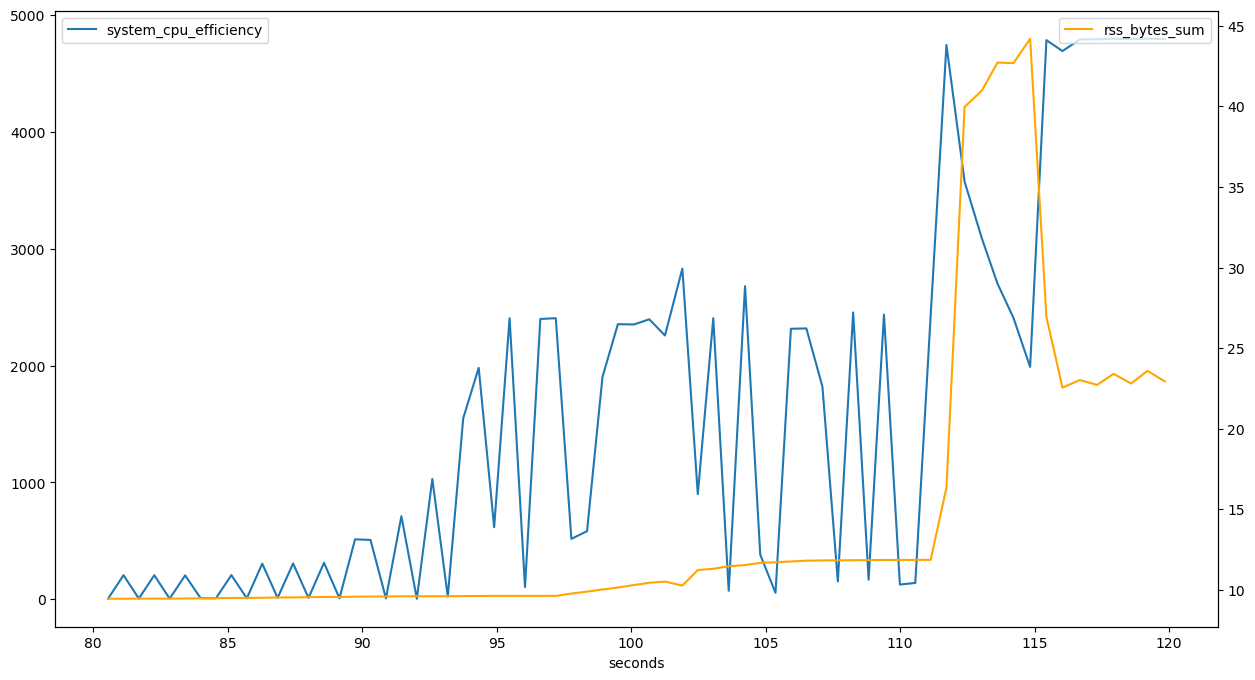

In [388]:
fig,ax = plt.subplots(figsize=(15,8))
start = pd.Timedelta('80 seconds')
end =  pd.Timedelta('120 seconds')
df.loc[start:end].set_index('seconds')[['system_cpu_efficiency']].plot(ax=ax)
ax2 = ax.twinx()
df.loc[start:end].set_index('seconds')[['rss_bytes_sum']].plot(ax=ax2,color='orange')

Let's track the next few iterations

<Axes: xlabel='seconds'>

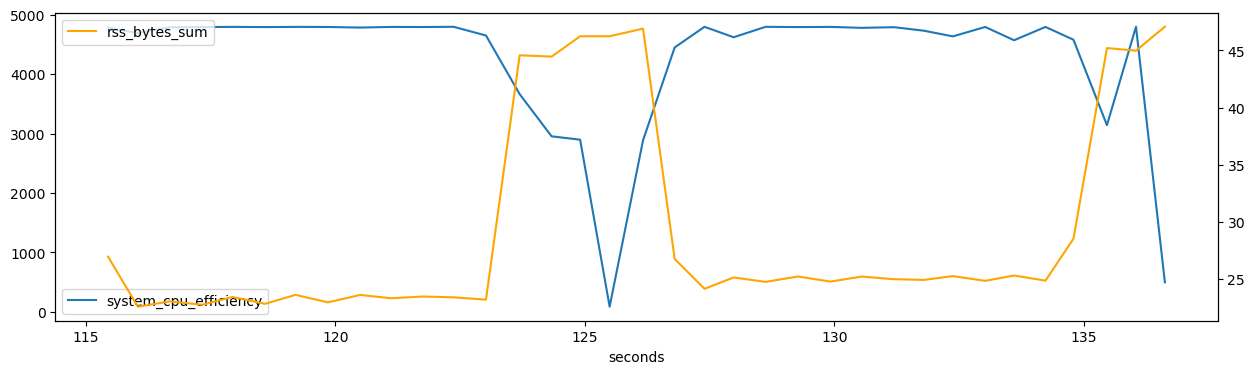

In [395]:
fig,ax = plt.subplots(figsize=(15,4))
start = pd.Timedelta('115 seconds')
end =  pd.Timedelta('137 seconds')
df.loc[start:end].set_index('seconds')[['system_cpu_efficiency']].plot(ax=ax)
ax2 = ax.twinx()
df.loc[start:end].set_index('seconds')[['rss_bytes_sum']].plot(ax=ax2,color='orange')

Let's try and overlay some disk I/O

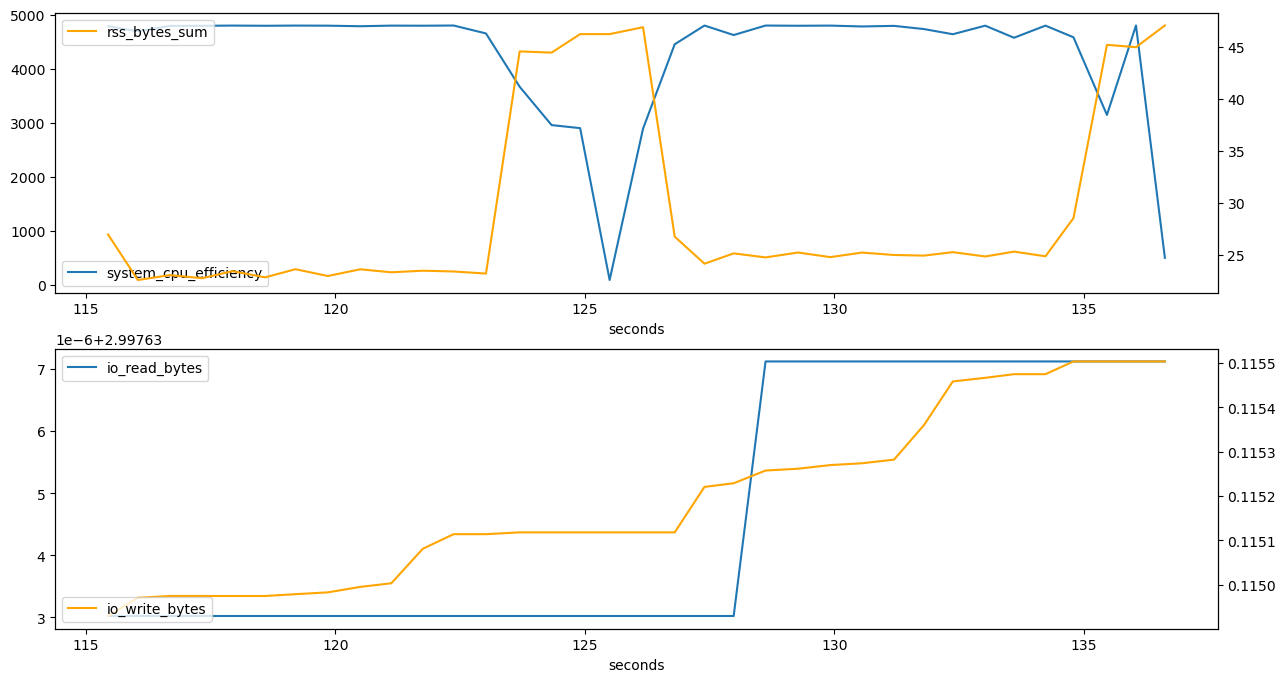

In [390]:
fig,ax = plt.subplots(2,1,figsize=(15,8))
df.loc[start:end].set_index('seconds')[['system_cpu_efficiency']].plot(ax=ax[0])
ax2 = ax[0].twinx()
df.loc[start:end].set_index('seconds')[['rss_bytes_sum']].plot(ax=ax2,color='orange')

df.loc[start:end].set_index('seconds')[['io_read_bytes']].plot(ax=ax[1])
ax3 = ax[1].twinx()
df.loc[start:end].set_index('seconds')[['io_write_bytes']].plot(ax=ax3,color='orange').legend(loc='lower left')
                                                                                                           

Expand for a longer window. Add network traffic

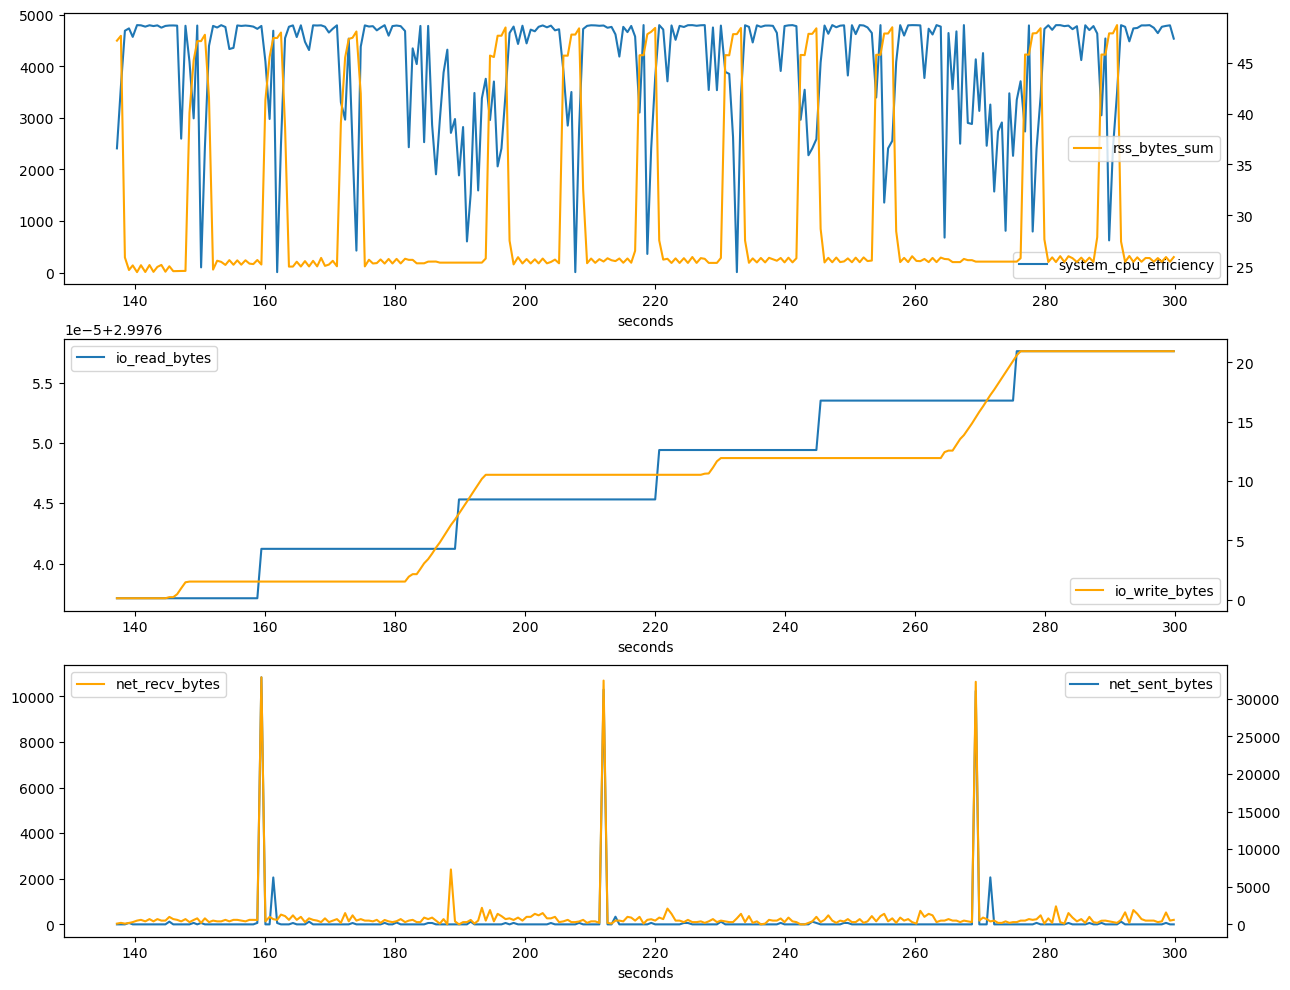

In [391]:
fig,ax = plt.subplots(3,1,figsize=(15,12))
start = pd.Timedelta('137 seconds')
end =  pd.Timedelta('300 seconds')
df.loc[start:end].set_index('seconds')[['system_cpu_efficiency']].plot(ax=ax[0])
ax2 = ax[0].twinx()
df.loc[start:end].set_index('seconds')[['rss_bytes_sum']].plot(ax=ax2,color='orange')

df.loc[start:end].set_index('seconds')[['io_read_bytes']].plot(ax=ax[1])
ax3 = ax[1].twinx()
df.loc[start:end].set_index('seconds')[['io_write_bytes']].plot(ax=ax3,color='orange').legend(loc='lower right')

df.loc[start:end].set_index('seconds')[['net_sent_bytes']].plot(ax=ax[2])
ax4 = ax[2].twinx()
df.loc[start:end].set_index('seconds')[['net_recv_bytes']].plot(ax=ax4,color='orange').legend(loc='upper left')

This implies the `io_<read|write>_bytes` fields are cumulative? Let's check.

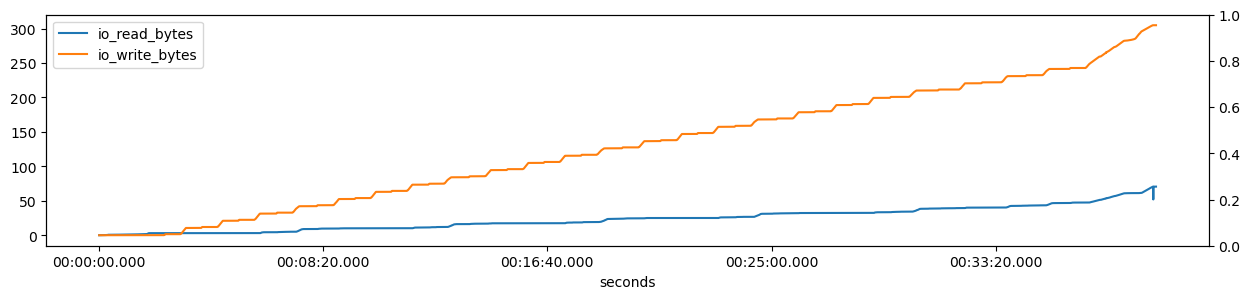

In [392]:
fig,ax = plt.subplots(figsize=(15,3))
df.set_index('seconds')[['io_read_bytes']].plot(ax=ax)
ax2 = ax.twinx()
df.set_index('seconds')[['io_write_bytes']].plot(ax=ax)
# Define formatter function for minutes and seconds
ax.xaxis.set_major_formatter(FuncFormatter(format_seconds_to_hms))

In [393]:
df.columns

Index(['allowed_cpus', 'booked_mem', 'booked_walltime', 'cpus_per_task',
       'event', 'job_id', 'job_name', 'num_nodes', 'project', 'queue', 't',
       'tasks_per_node', 'user_id', 'cpu_pct_sum', 'rss_bytes_sum', 'n_procs',
       'system_percpu_pct', 'tree_percpu_pct', 'system_cpu_efficiency',
       'n_threads', 'n_open_fds', 'major_faults', 'minor_faults',
       'io_read_bytes', 'io_write_bytes', 'io_read_ops', 'io_write_ops',
       'swap_bytes', 'net_recv_bytes', 'net_sent_bytes', 'net_recv_packets',
       'net_sent_packets', 'gpu_utilization', 'gpu_memory_used',
       'gpu_memory_total', 'gpu_temperature', 'gpu_power', 'time', 'seconds'],
      dtype='object')